In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy
from torchdiffeq import odeint as torchodeint
from tqdm import tqdm
import torch.nn as nn
import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")

from kan import KAN as efficientkan #from efficient kan
from RBF_KAN_multiquadratic import RBFKAN
from ChebyKANLayer import ChebyKANLayer
from fastkan import FastKAN


In [11]:
def plotter(pred, soln_arr, epoch, loss_train, loss_test):
    #callback plotter during training, plots current solution
    plt.close('all')
    plt.figure()
    plt.plot(t, soln_arr[:, 0].detach(), color='g')
    plt.plot(t, soln_arr[:, 1].detach(), color='b')
    plt.plot(t, pred[:, 0].detach(), linestyle='dashed', color='g')
    plt.plot(t, pred[:, 1].detach(), linestyle='dashed', color='b')

    plt.legend(['x_data', 'y_data', 'x_KAN-ODE', 'y_KAN-ODE'])
    plt.ylabel('concentration')
    plt.xlabel('time')
    plt.vlines(tf_learn, 0, 5)
    #plt.savefig("plots/pred_prey/training_updates/train_epoch_"+str(epoch) +".png", dpi=200, facecolor="w", edgecolor="w", orientation="portrait")
    
    plt.figure()
    plt.semilogy(torch.Tensor(loss_train), label='train')
    plt.semilogy(torch.Tensor(loss_test), label='test')
    plt.legend()
    plt.xlabel('epoch')
    plt.ylabel('loss')
    #plt.savefig("plots/pred_prey/loss.png", dpi=200, facecolor="w", edgecolor="w", orientation="portrait")
    plt.show()
    
def plotter_opt(pred, soln_arr, epoch, loss_train, loss_test):
    #plots the optimal solution 
    plt.figure()
    plt.plot(t, soln_arr[:, 0].detach(), color='g')
    plt.plot(t, soln_arr[:, 1].detach(), color='b')
    plt.plot(t, pred[:, 0].detach(), linestyle='dashed', color='g')
    plt.plot(t, pred[:, 1].detach(), linestyle='dashed', color='b')

    plt.legend(['x_data', 'y_data', 'x_KAN-ODE', 'y_KAN-ODE'])
    plt.ylabel('concentration')
    plt.xlabel('time')
    plt.vlines(tf_learn, 0, 5)
    #plt.savefig("plots/pred_prey/optimal/train_trial_.png", dpi=200, facecolor="w", edgecolor="w", orientation="portrait")
    plt.show()

def plotPhaseSpace(pred, soln_arr):
    #plots the phase space of the solution array continging two variables
    plt.figure()
    plt.plot(soln_arr[:, 0].detach(), soln_arr[:, 1].detach())
    plt.plot(pred[:, 0].detach(), pred[:, 1].detach())
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

In [12]:
def calDeriv(t, X):
    dXdt=model(X)
    return dXdt

def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

def duffing_deriv(X, t, alpha, beta, delta, gamma, omega):
    x = X[0]
    y = X[1]
    y_dot = gamma*np.cos(omega*t) - beta*x**3 - alpha*x - delta*y
    return [y, y_dot]

In [13]:

tf=10
tf_learn=4
N_t_train=800
N_t=int((N_t_train*tf/tf_learn))
lr=2e-3
num_epochs=1000
plot_freq=100
is_restart=False


##coefficients from https://arxiv.org/pdf/2012.07244
alpha=1.5
beta=1
gamma=2
delta=1
x0 = 1
y0 = 1

In [59]:
class LVChebyKAN(nn.Module):
    def __init__(self):
        super(LVChebyKAN, self).__init__()
        self.chebykan1 = ChebyKANLayer(2, 10, 4)
        self.ln1 = nn.LayerNorm(10) # To avoid gradient vanishing caused by tanh
        self.chebykan2 = ChebyKANLayer(10, 2, 4)
        #self.ln2 = nn.LayerNorm(10)
        #self.chebykan3 = ChebyKANLayer(10, 2, 4)

    def forward(self, x):
        x = self.chebykan1(x)
        x = self.ln1(x)
        x = self.chebykan2(x)
        #x = self.ln2(x)
        #x = self.chebykan3(x)
        return x

In [60]:
#model = RBFKAN(2, 10, 2, 10)#convery numpy training data to torch tensors: 
#model = efficientkan(layers_hidden=[2,10,2], grid_size=5) #k is order of piecewise polynomial
model = LVChebyKAN()

In [16]:
X0=np.array([x0, y0])
t=np.linspace(0, tf, N_t)
soln_arr=scipy.integrate.odeint(pred_prey_deriv, X0, t, args=(alpha, beta, delta, gamma))

X0=torch.unsqueeze((torch.Tensor(np.transpose(X0))), 0)
X0.requires_grad=True
soln_arr=torch.Tensor(soln_arr)
soln_arr.requires_grad=True
soln_arr_train=soln_arr[:N_t_train, :]
t=torch.Tensor(t)
t_learn=torch.tensor(np.linspace(0, tf_learn, N_t_train))

  0%|                                                                                         | 0/1000 [00:00<?, ?it/s]

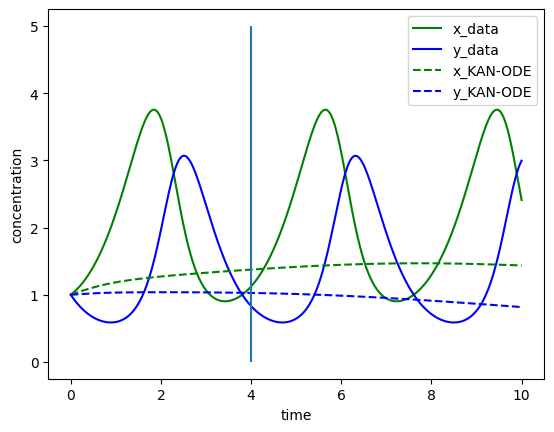

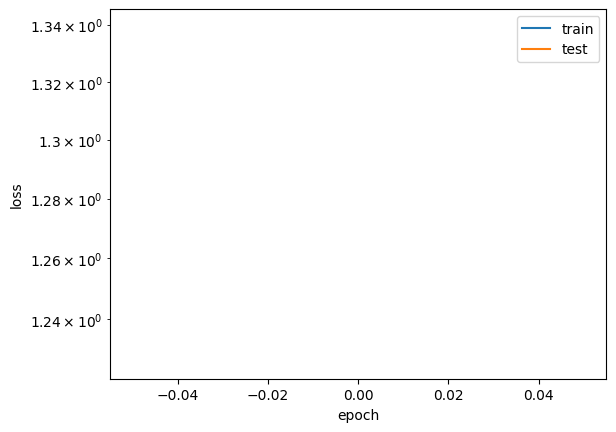

 10%|███████▉                                                                       | 100/1000 [01:13<14:20,  1.05it/s]

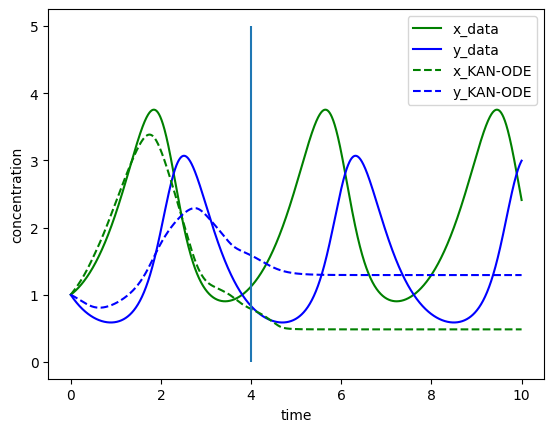

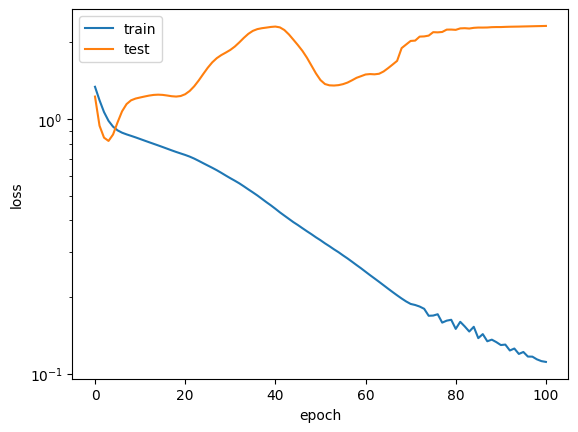

 20%|███████████████▊                                                               | 200/1000 [02:55<14:45,  1.11s/it]

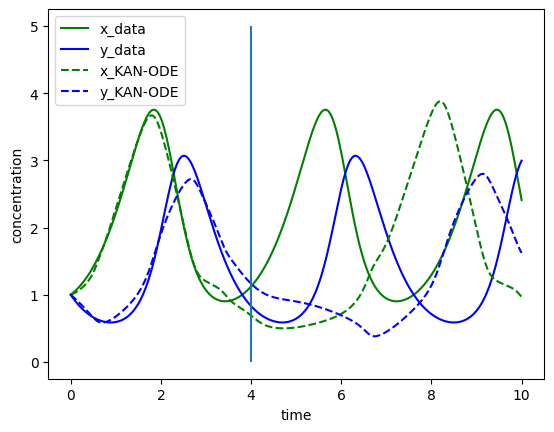

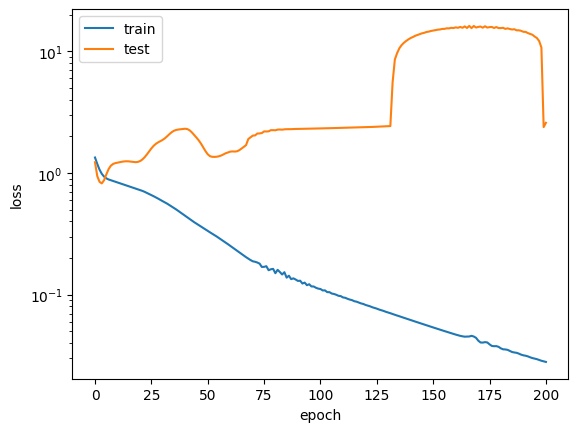

 30%|███████████████████████▋                                                       | 300/1000 [04:50<13:47,  1.18s/it]

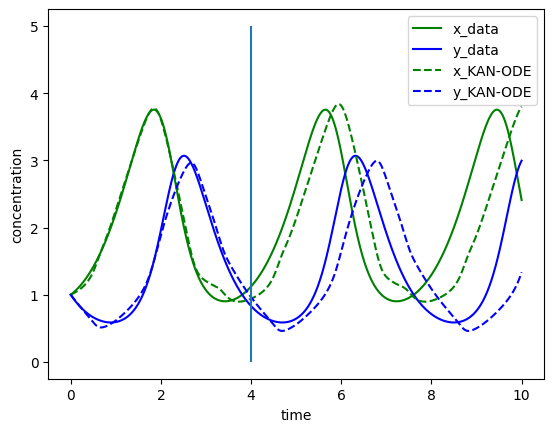

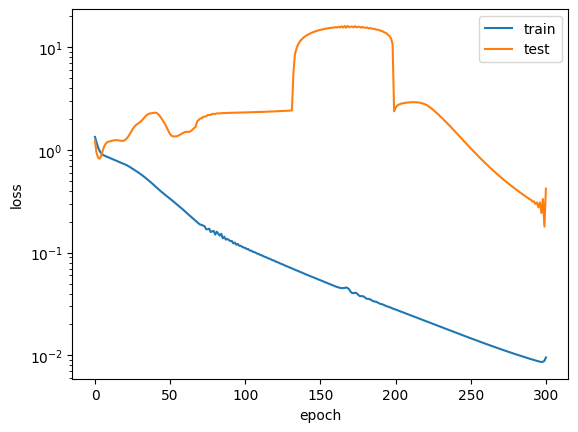

 40%|███████████████████████████████▌                                               | 400/1000 [06:47<11:25,  1.14s/it]

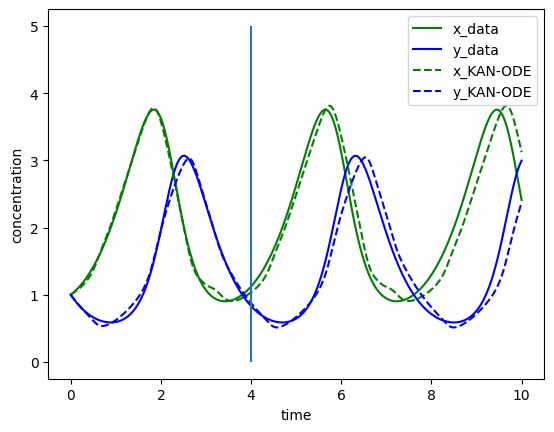

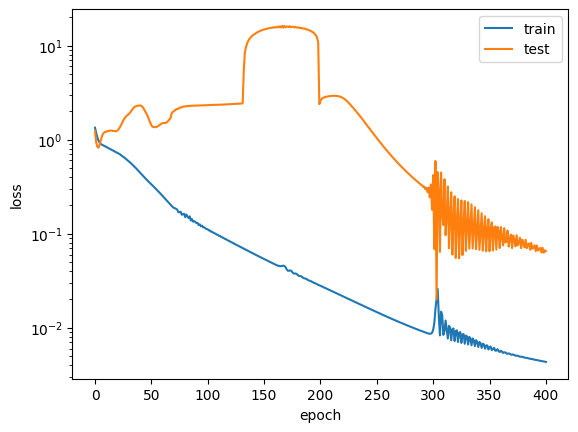

 50%|███████████████████████████████████████▌                                       | 500/1000 [08:44<09:35,  1.15s/it]

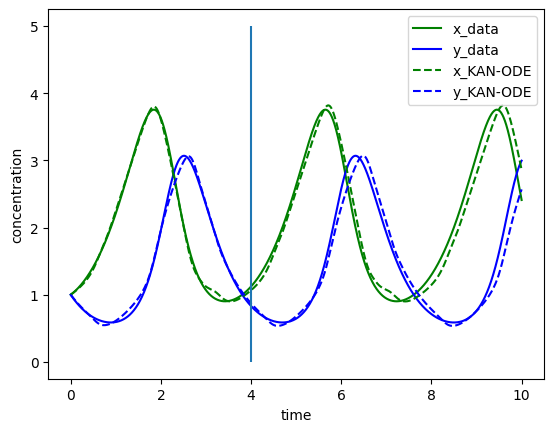

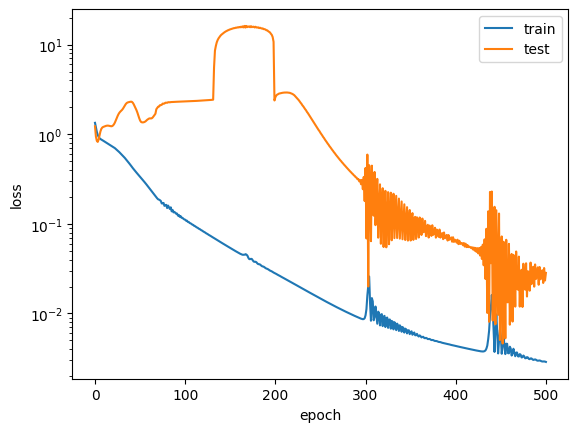

 60%|███████████████████████████████████████████████▍                               | 600/1000 [10:41<07:48,  1.17s/it]

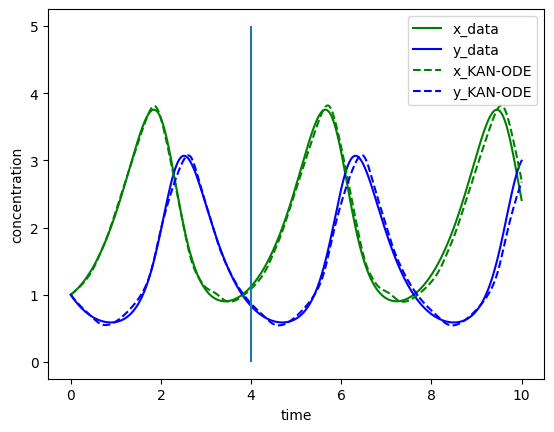

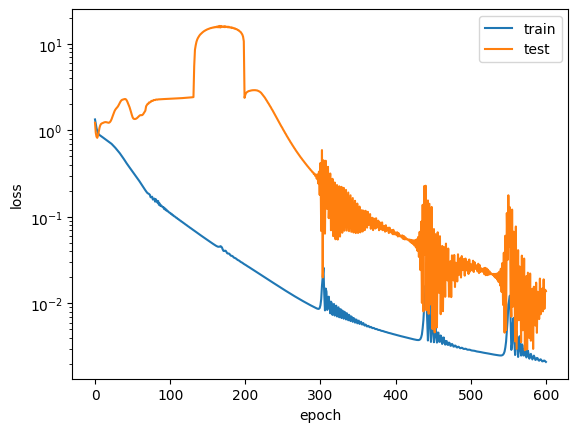

 70%|███████████████████████████████████████████████████████▎                       | 700/1000 [12:38<05:56,  1.19s/it]

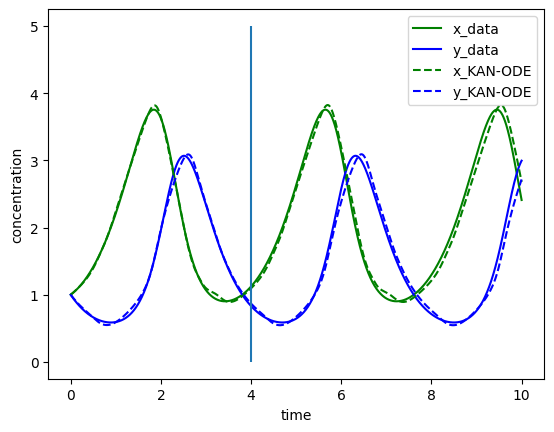

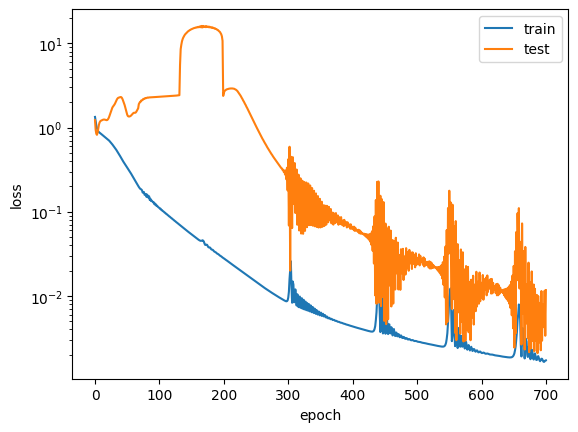

 80%|███████████████████████████████████████████████████████████████▏               | 800/1000 [14:34<03:52,  1.16s/it]

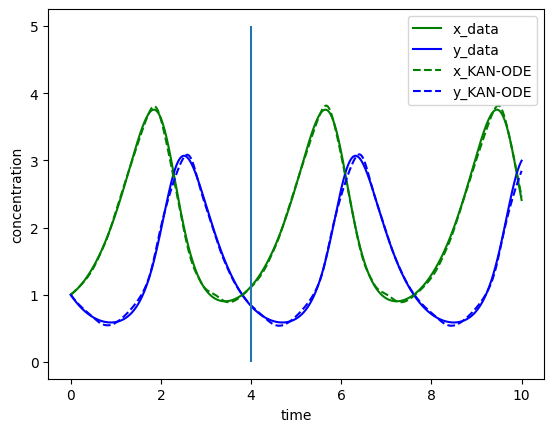

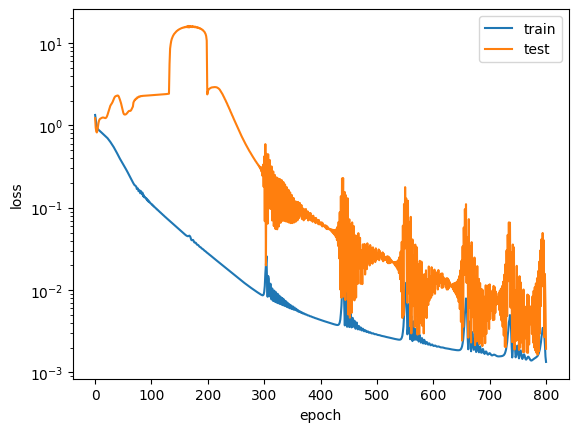

 90%|███████████████████████████████████████████████████████████████████████        | 900/1000 [16:32<01:54,  1.15s/it]

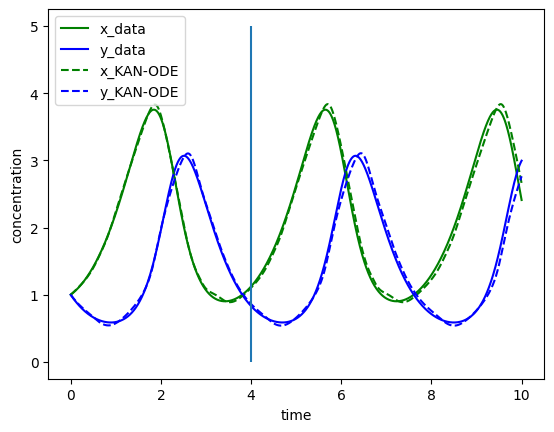

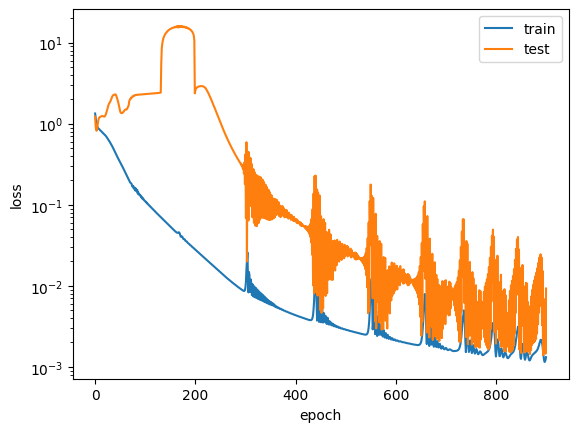

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [18:29<00:00,  1.11s/it]


In [63]:
loss_list_train=[]
loss_list_test=[]
#initialize ADAM optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


loss_min=1e10 #arbitrarily large to overwrite later
opt_plot_counter=0

epoch_cutoff=10 #start at smaller lr to initialize, then bump it up

#p1=model.layers[0].spline_weight
#p2=model.layers[0].base_weight
#p3=model.layers[1].spline_weight
#p4=model.layers[1].base_weight
for epoch in tqdm(range(num_epochs)):
    #if epoch==epoch_cutoffs[2]:
    #    model = kan.KAN(width=[2,3,2], grid=grids[1], k=3).initialize_from_another_model(model, X0_train)
    model.train()
    optimizer.zero_grad()

    #pred=torchodeint(calDeriv, X0, t_learn, adjoint_params=[p1, p2, p3, p4])
    pred=torchodeint(calDeriv, X0, t_learn)
    loss_train=torch.mean(torch.square(pred[:, 0, :]-soln_arr_train))
    loss_train.retain_grad()
    loss_train.backward()
    optimizer.step()
    loss_list_train.append(loss_train.detach().cpu())
    #pred_test=torchodeint(calDeriv, X0, t, adjoint_params=[])
    model.eval()
    pred_test=torchodeint(calDeriv, X0, t)
    loss_list_test.append(torch.mean(torch.square(pred_test[N_t_train:,0, :]-soln_arr[N_t_train:, :])).detach().cpu())
    if epoch % plot_freq == 0:
        plotter(pred_test[:, 0, :], soln_arr, epoch, loss_list_train, loss_list_test)
    

In [17]:
model = FastKAN([2, 10, 2])

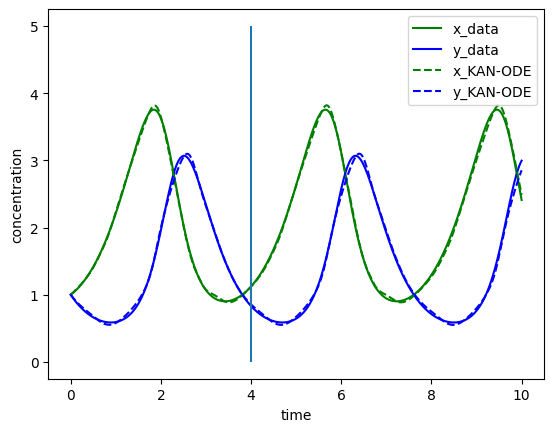

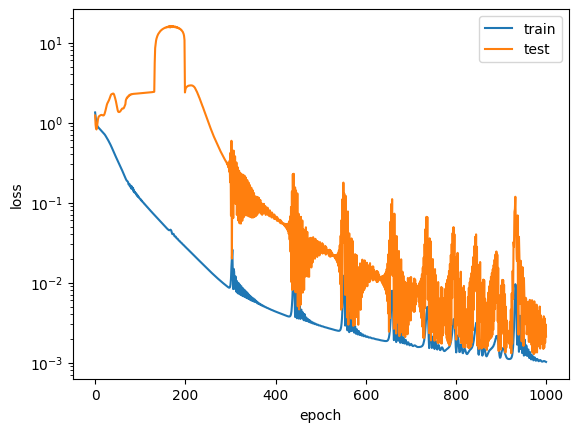

In [64]:
plotter(pred_test[:, 0, :], soln_arr, epoch, loss_list_train, loss_list_test)

  0%|                                                                                         | 0/1000 [00:00<?, ?it/s]

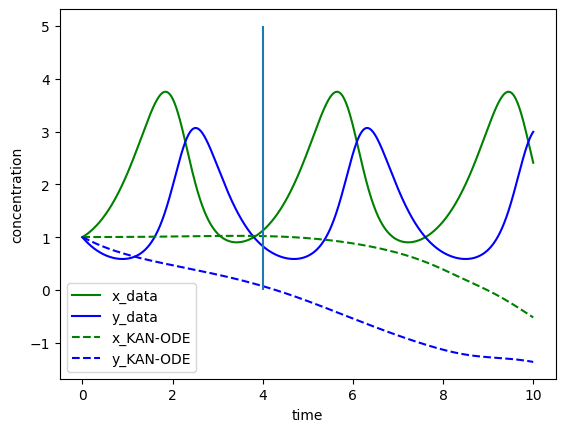

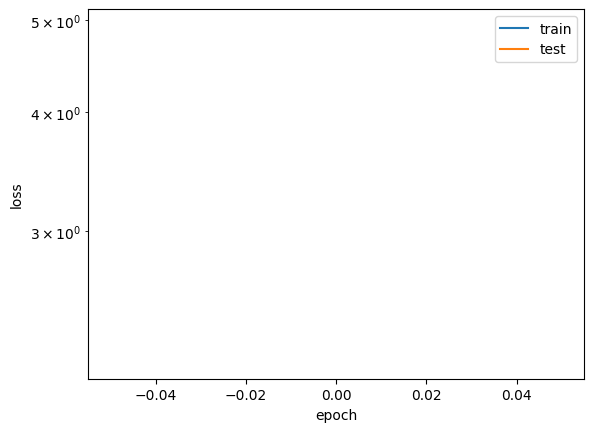

 10%|███████▉                                                                       | 100/1000 [02:16<18:01,  1.20s/it]

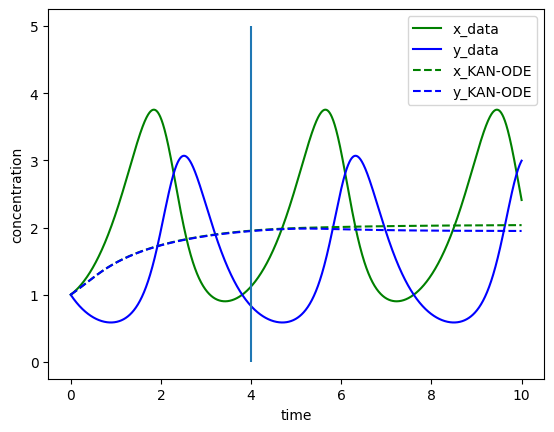

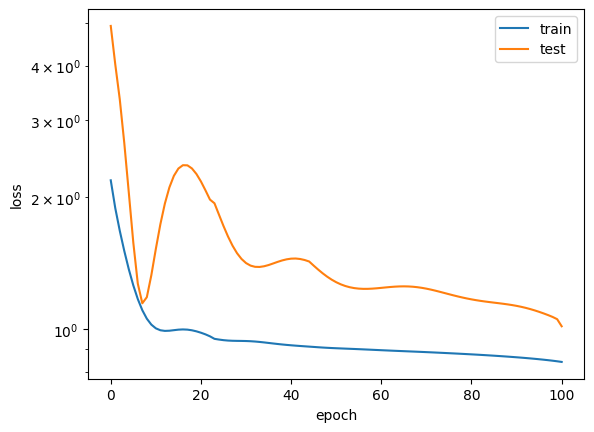

 20%|███████████████▊                                                               | 200/1000 [04:18<12:30,  1.07it/s]

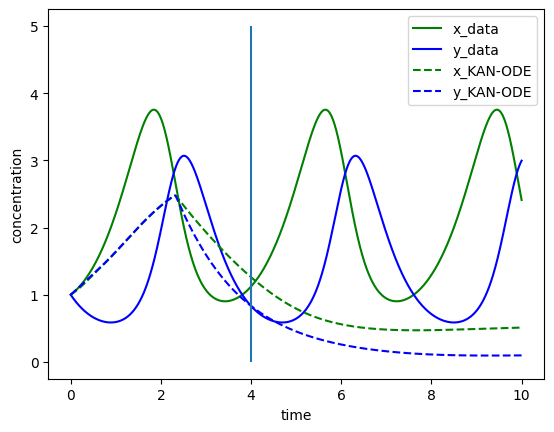

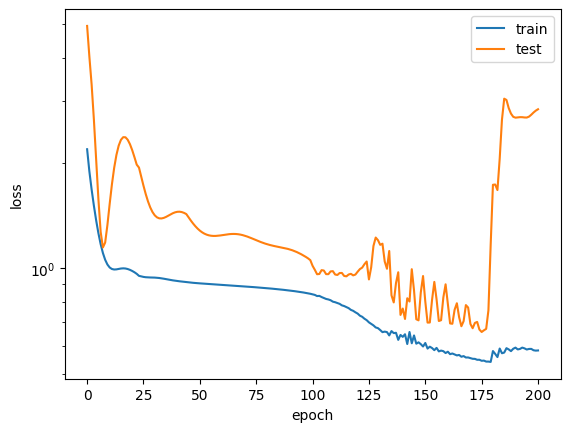

 30%|███████████████████████▋                                                       | 300/1000 [06:32<13:01,  1.12s/it]

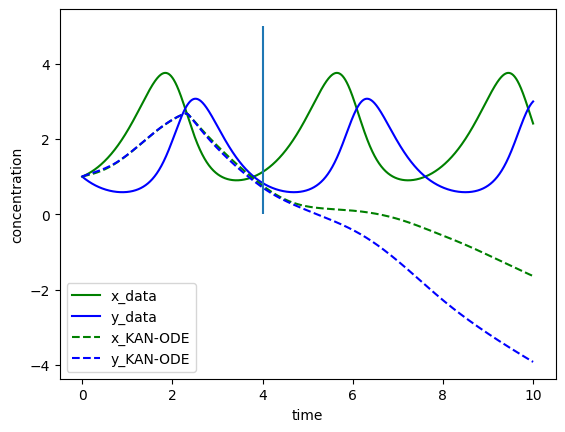

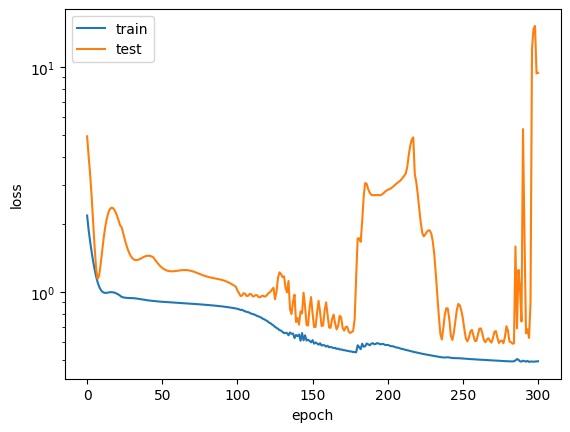

 40%|███████████████████████████████▌                                               | 400/1000 [08:01<09:38,  1.04it/s]

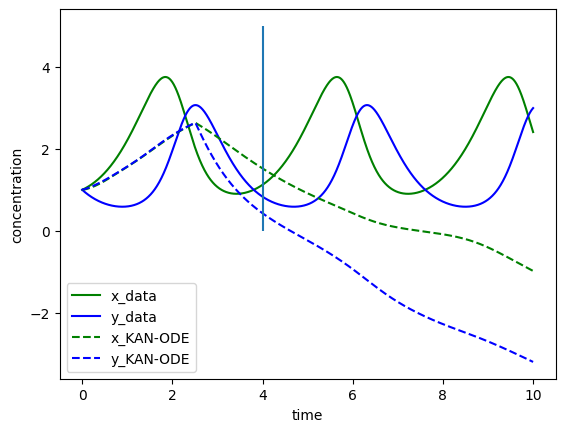

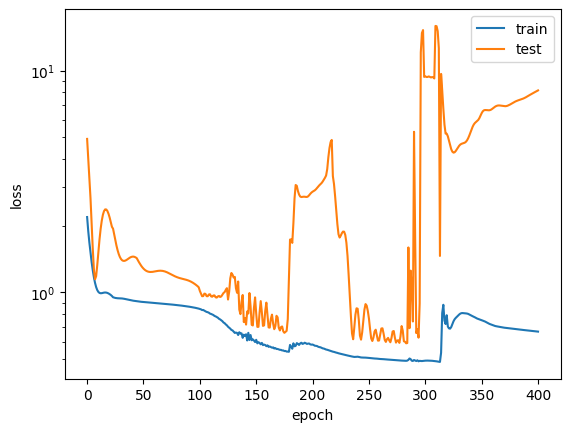

 50%|███████████████████████████████████████▌                                       | 500/1000 [09:38<07:56,  1.05it/s]

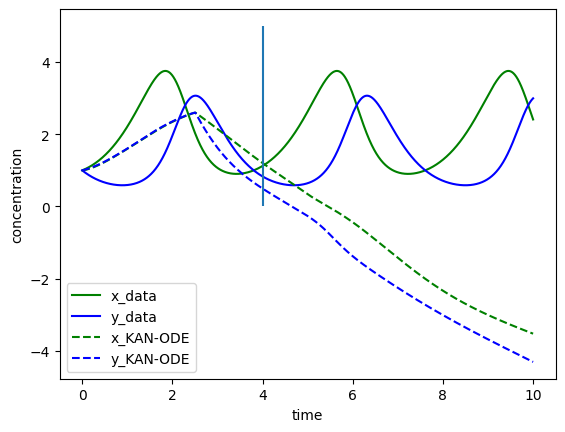

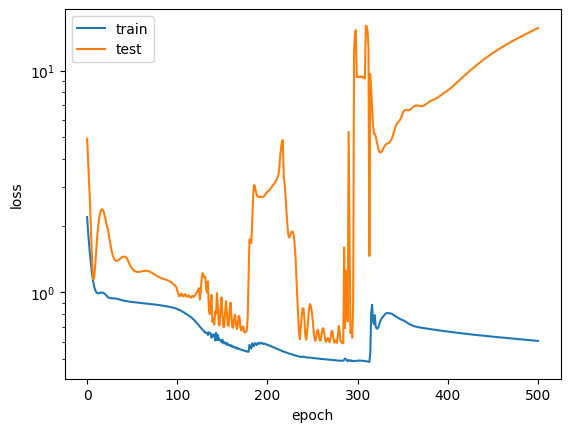

 60%|███████████████████████████████████████████████▍                               | 600/1000 [11:14<06:24,  1.04it/s]

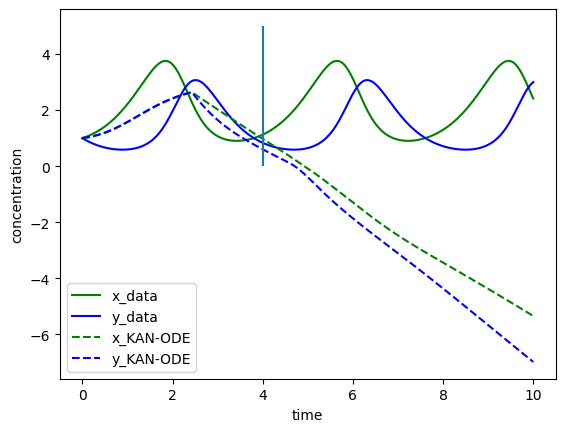

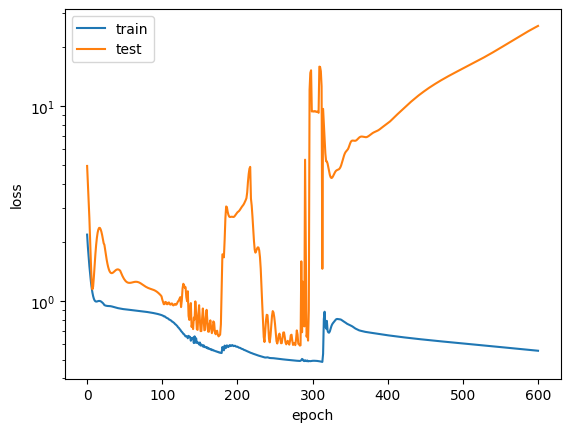

 70%|███████████████████████████████████████████████████████▎                       | 700/1000 [12:56<06:23,  1.28s/it]

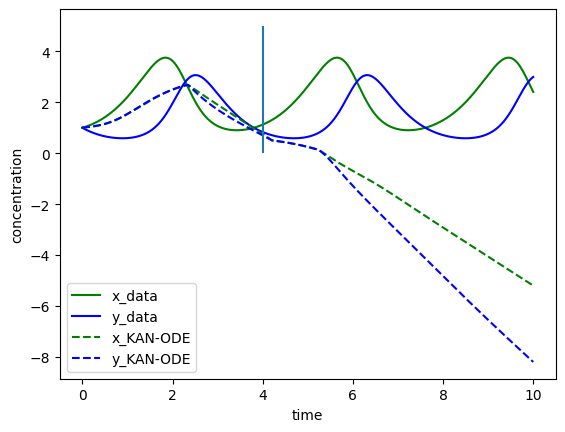

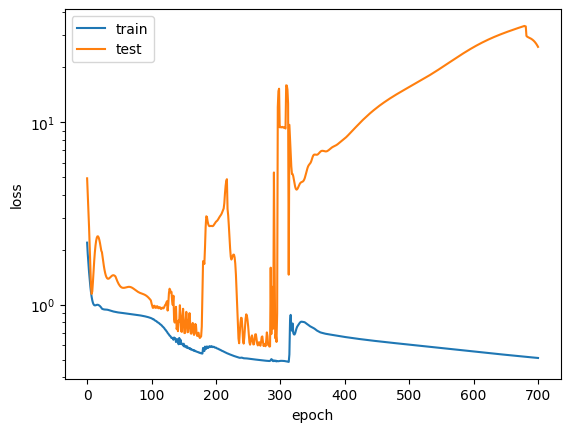

 80%|███████████████████████████████████████████████████████████████▏               | 800/1000 [15:35<05:16,  1.58s/it]

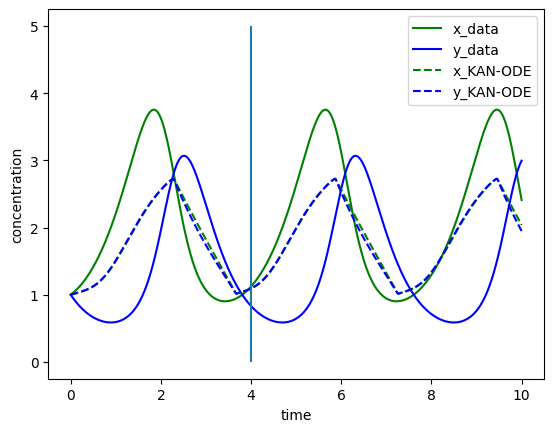

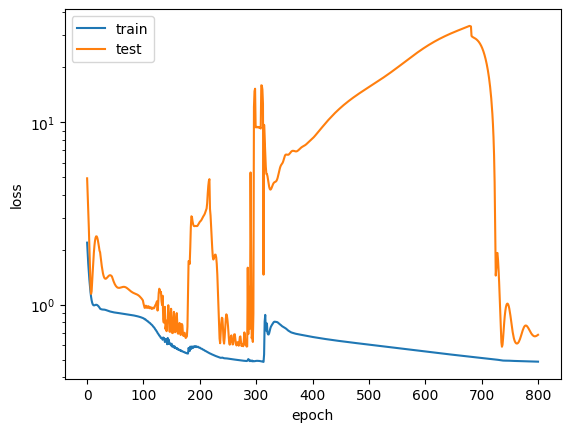

 90%|███████████████████████████████████████████████████████████████████████        | 900/1000 [18:12<02:09,  1.30s/it]

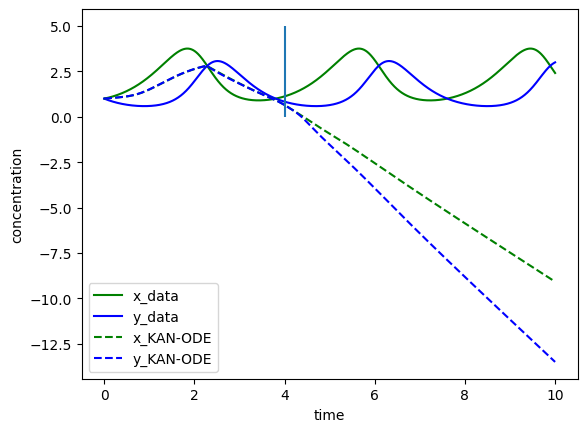

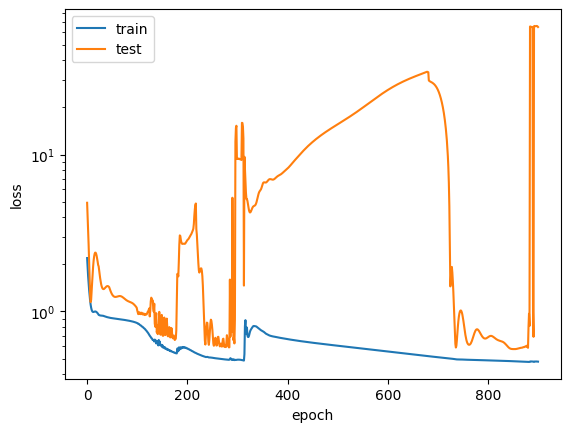

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [20:39<00:00,  1.24s/it]


In [18]:
loss_list_train=[]
loss_list_test=[]
#initialize ADAM optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


loss_min=1e10 #arbitrarily large to overwrite later
opt_plot_counter=0

epoch_cutoff=10 #start at smaller lr to initialize, then bump it up

#p1=model.layers[0].spline_weight
#p2=model.layers[0].base_weight
#p3=model.layers[1].spline_weight
#p4=model.layers[1].base_weight
for epoch in tqdm(range(num_epochs)):
    #if epoch==epoch_cutoffs[2]:
    #    model = kan.KAN(width=[2,3,2], grid=grids[1], k=3).initialize_from_another_model(model, X0_train)
    model.train()
    optimizer.zero_grad()

    #pred=torchodeint(calDeriv, X0, t_learn, adjoint_params=[p1, p2, p3, p4])
    pred=torchodeint(calDeriv, X0, t_learn)
    loss_train=torch.mean(torch.square(pred[:, 0, :]-soln_arr_train))
    loss_train.retain_grad()
    loss_train.backward()
    optimizer.step()
    loss_list_train.append(loss_train.detach().cpu())
    #pred_test=torchodeint(calDeriv, X0, t, adjoint_params=[])
    model.eval()
    pred_test=torchodeint(calDeriv, X0, t)
    loss_list_test.append(torch.mean(torch.square(pred_test[N_t_train:,0, :]-soln_arr[N_t_train:, :])).detach().cpu())
    if epoch % plot_freq == 0:
        plotter(pred_test[:, 0, :], soln_arr, epoch, loss_list_train, loss_list_test)
    

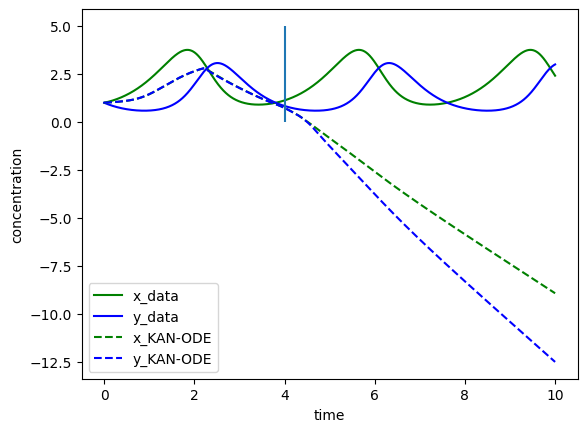

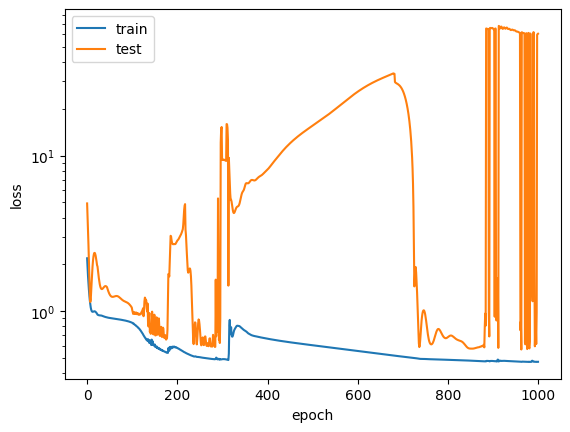

In [19]:
plotter(pred_test[:, 0, :], soln_arr, epoch, loss_list_train, loss_list_test)